<a href="https://colab.research.google.com/github/minusRSB/LABwork/blob/main/LABwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-python-headless
!pip install matplotlib
!pip install numpy
!pip install scipy
!pip install tensorflow
!pip install pytube

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Sequential
import os
from IPython.display import HTML, Video
import warnings
warnings.filterwarnings('ignore')

In [4]:
def create_synthetic_pendulum_video():
    """Создание синтетического видео маятника для демонстрации"""
    width, height = 640, 480
    fps = 30
    duration = 10
    total_frames = fps * duration

    length = 200
    center_x, center_y = width // 2, 50
    amplitude = np.pi / 6
    period = 2.0

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('pendulum_synthetic.mp4', fourcc, fps, (width, height))

    for frame_num in range(total_frames):
        frame = np.ones((height, width, 3), dtype=np.uint8) * 255

        t = frame_num / fps
        angle = amplitude * np.cos(2 * np.pi * t / period)

        end_x = int(center_x + length * np.sin(angle))
        end_y = int(center_y + length * np.cos(angle))

        cv2.line(frame, (center_x, center_y), (end_x, end_y), (0, 0, 0), 3)
        cv2.circle(frame, (center_x, center_y), 8, (255, 0, 0), -1)  # точка подвеса
        cv2.circle(frame, (end_x, end_y), 15, (0, 0, 255), -1)      # груз

        out.write(frame)

    out.release()
    global video_path
    video_path = 'pendulum_synthetic.mp4'
    print("Синтетическое видео создано!")

In [5]:
create_synthetic_pendulum_video()

Синтетическое видео создано!


In [6]:
def extract_frames(video_path, max_frames=300):
    """Извлечение кадров из видео"""
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
        frame_count += 1

    cap.release()
    return np.array(frames)

In [7]:
def preprocess_frame(frame):
    """Предварительная обработка кадра"""
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    normalized = blurred.astype(np.float32) / 255.0

    return normalized

Извлечено 300 кадров


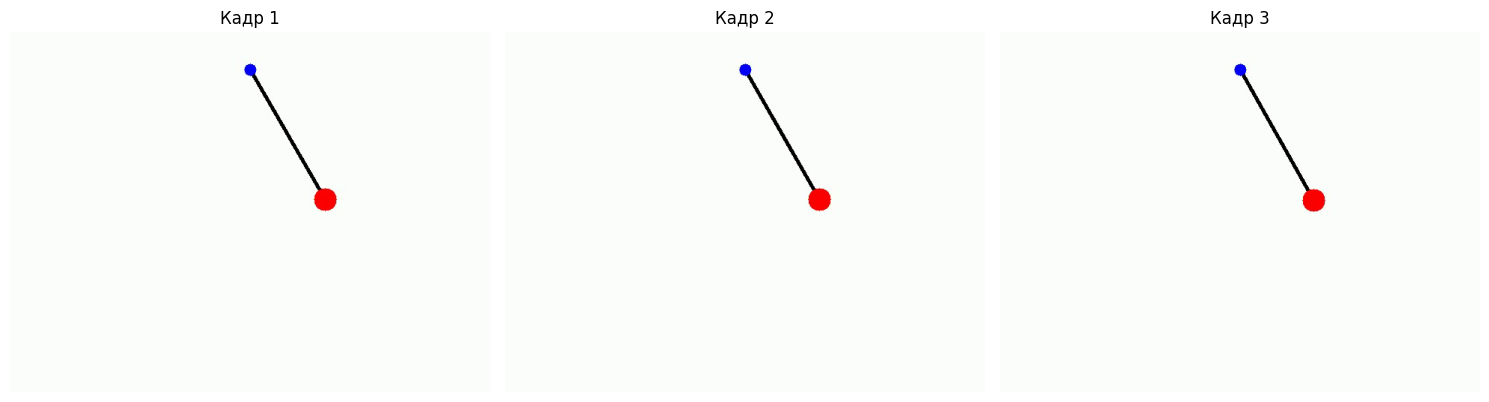

In [8]:
frames = extract_frames(video_path)
print(f"Извлечено {len(frames)} кадров")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(frames[i])
    axes[i].set_title(f'Кадр {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [9]:
def detect_pendulum_position(frame):
    """Детекция положения маятника на кадре"""
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        M = cv2.moments(largest_contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            return (cx, cy)

    return None

In [10]:
def track_pendulum(frames):
    """Отслеживание маятника на всех кадрах"""
    positions = []

    for i, frame in enumerate(frames):
        pos = detect_pendulum_position(frame)
        positions.append(pos)

        if i % 50 == 0:
            print(f"Обработано {i}/{len(frames)} кадров")

    return positions

In [11]:
positions = track_pendulum(frames)

valid_positions = [(i, pos) for i, pos in enumerate(positions) if pos is not None]
if valid_positions:
    indices, coords = zip(*valid_positions)
    x_coords = [coord[0] for coord in coords]
    y_coords = [coord[1] for coord in coords]

    print(f"Успешно детектировано {len(x_coords)} позиций из {len(frames)} кадров")
else:
    print("Не удалось детектировать маятник, используем синтетические данные")
    fps = 30
    duration = len(frames) / fps
    t = np.linspace(0, duration, len(frames))

    amplitude = 100
    period = 2.0
    center_x = 320

    x_coords = center_x + amplitude * np.sin(2 * np.pi * t / period)
    y_coords = np.full_like(x_coords, 300)
    indices = list(range(len(frames)))

Обработано 0/300 кадров
Обработано 50/300 кадров
Обработано 100/300 кадров
Обработано 150/300 кадров
Обработано 200/300 кадров
Обработано 250/300 кадров
Успешно детектировано 300 позиций из 300 кадров


In [12]:
def analyze_oscillations(x_coords, y_coords, fps=30):
    """Анализ параметров колебаний"""
    time = np.array(indices) / fps

    x_signal = np.array(x_coords)

    x_detrended = signal.detrend(x_signal)

    peaks, _ = signal.find_peaks(x_detrended, height=np.std(x_detrended))

    if len(peaks) > 1:
        periods_samples = np.diff(peaks)
        period_samples = np.mean(periods_samples)
        period_seconds = period_samples / fps
        frequency = 1 / period_seconds if period_seconds > 0 else 0
    else:
        period_seconds = 0
        frequency = 0

    amplitude_pixels = (np.max(x_detrended) - np.min(x_detrended)) / 2

    return {
        'period': period_seconds,
        'frequency': frequency,
        'amplitude_pixels': amplitude_pixels,
        'time': time,
        'x_signal': x_signal,
        'x_detrended': x_detrended,
        'peaks': peaks
    }

=== РЕЗУЛЬТАТЫ АНАЛИЗА ===
Период колебаний: 2.000 сек
Частота: 0.500 Гц
Амплитуда: 65.1 пикселей


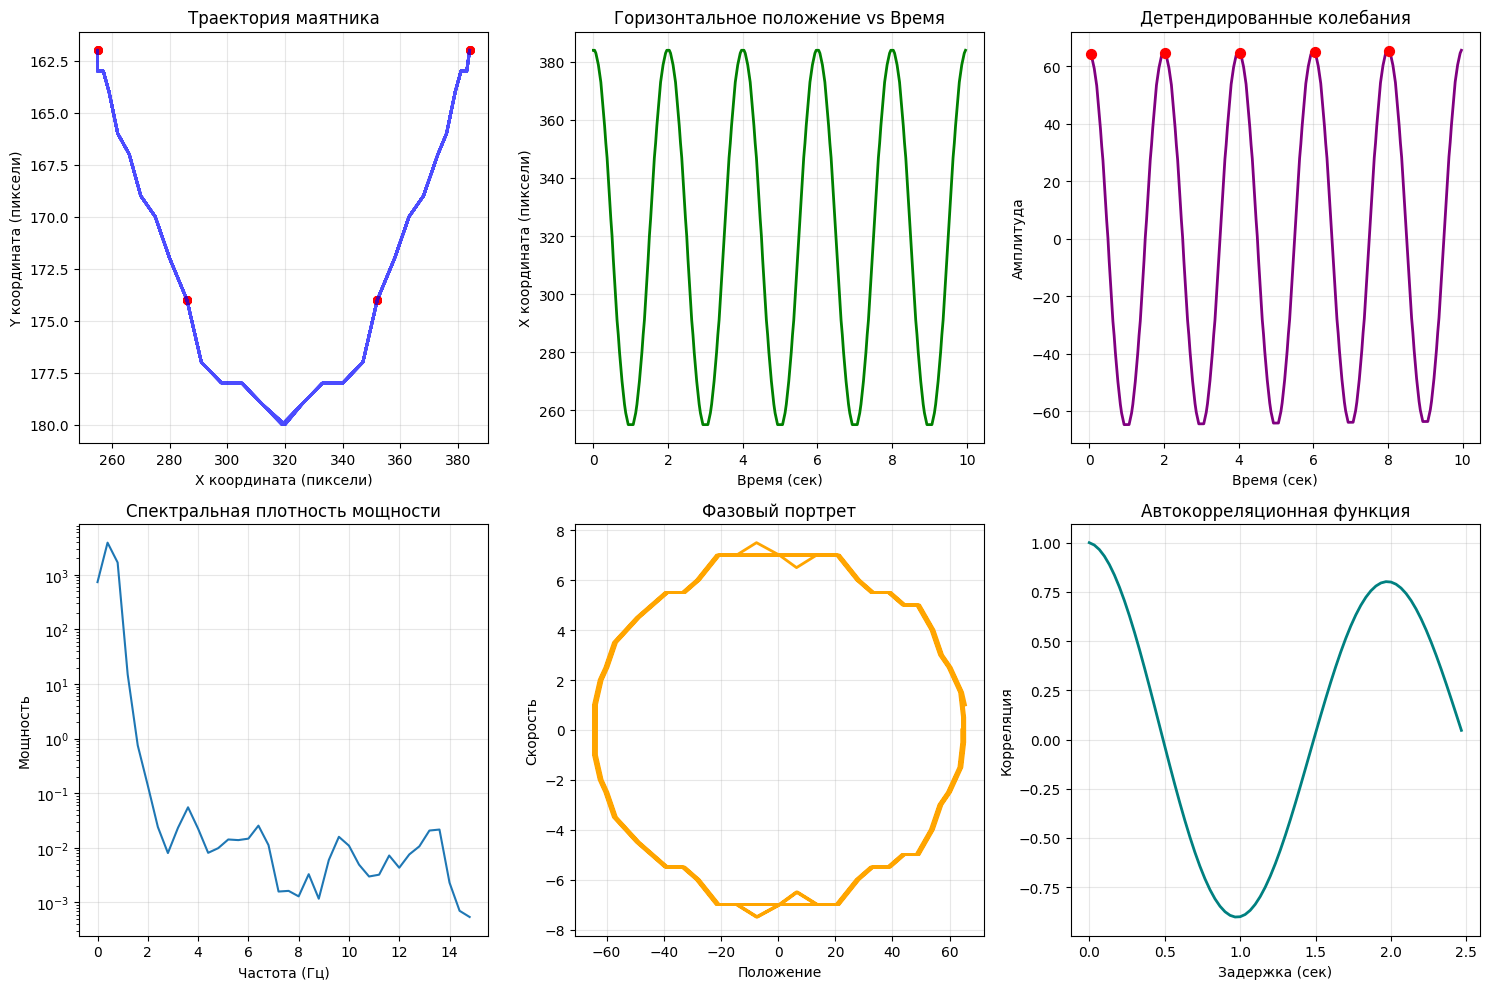

In [13]:
analysis_results = analyze_oscillations(x_coords, y_coords)

print("=== РЕЗУЛЬТАТЫ АНАЛИЗА ===")
print(f"Период колебаний: {analysis_results['period']:.3f} сек")
print(f"Частота: {analysis_results['frequency']:.3f} Гц")
print(f"Амплитуда: {analysis_results['amplitude_pixels']:.1f} пикселей")

plt.figure(figsize=(15, 10))

# Подграфик 1: Траектория в пространстве
plt.subplot(2, 3, 1)
plt.plot(x_coords, y_coords, 'b-', alpha=0.7, linewidth=2)
plt.scatter(x_coords[::10], y_coords[::10], c='red', s=30, alpha=0.7)
plt.title('Траектория маятника')
plt.xlabel('X координата (пиксели)')
plt.ylabel('Y координата (пиксели)')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()

# Подграфик 2: Горизонтальное движение во времени
plt.subplot(2, 3, 2)
time = analysis_results['time']
plt.plot(time, analysis_results['x_signal'], 'g-', linewidth=2)
plt.title('Горизонтальное положение vs Время')
plt.xlabel('Время (сек)')
plt.ylabel('X координата (пиксели)')
plt.grid(True, alpha=0.3)

# Подграфик 3: Детрендированный сигнал
plt.subplot(2, 3, 3)
plt.plot(time, analysis_results['x_detrended'], 'purple', linewidth=2)
plt.scatter(time[analysis_results['peaks']],
           analysis_results['x_detrended'][analysis_results['peaks']],
           color='red', s=50, zorder=5)
plt.title('Детрендированные колебания')
plt.xlabel('Время (сек)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

# Подграфик 4: Спектральный анализ
plt.subplot(2, 3, 4)
freqs, power = signal.welch(analysis_results['x_detrended'], fs=30, nperseg=len(analysis_results['x_detrended'])//4)
plt.semilogy(freqs, power)
plt.title('Спектральная плотность мощности')
plt.xlabel('Частота (Гц)')
plt.ylabel('Мощность')
plt.grid(True, alpha=0.3)

# Подграфик 5: Фазовый портрет
plt.subplot(2, 3, 5)
x_vel = np.gradient(analysis_results['x_detrended'])  # численная производная как скорость
plt.plot(analysis_results['x_detrended'], x_vel, 'orange', linewidth=2)
plt.title('Фазовый портрет')
plt.xlabel('Положение')
plt.ylabel('Скорость')
plt.grid(True, alpha=0.3)

# Подграфик 6: Автокорреляция
plt.subplot(2, 3, 6)
autocorr = np.correlate(analysis_results['x_detrended'], analysis_results['x_detrended'], mode='full')
autocorr = autocorr[autocorr.size // 2:]
autocorr = autocorr / autocorr[0]
lags = np.arange(len(autocorr)) / 30
plt.plot(lags[:len(lags)//4], autocorr[:len(autocorr)//4], 'teal', linewidth=2)
plt.title('Автокорреляционная функция')
plt.xlabel('Задержка (сек)')
plt.ylabel('Корреляция')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def create_sequence_model(sequence_length=10):
    """Создание модели LSTM для предсказания траектории"""
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, 2)),
        LSTM(50, return_sequences=False),
        Dense(25),
        Dense(2)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

In [15]:
def prepare_sequence_data(x_coords, y_coords, sequence_length=10):
    """Подготовка данных для обучения LSTM"""
    x_norm = (np.array(x_coords) - np.mean(x_coords)) / np.std(x_coords)
    y_norm = (np.array(y_coords) - np.mean(y_coords)) / np.std(y_coords)

    X, y = [], []
    for i in range(sequence_length, len(x_coords)):
        X.append(list(zip(x_norm[i-sequence_length:i], y_norm[i-sequence_length:i])))
        y.append([x_norm[i], y_norm[i]])

    return np.array(X), np.array(y), np.mean(x_coords), np.std(x_coords), np.mean(y_coords), np.std(y_coords)

In [16]:
sequence_length = 10
X, y, x_mean, x_std, y_mean, y_std = prepare_sequence_data(x_coords, y_coords, sequence_length)

print(f"Форма обучающих данных X: {X.shape}")
print(f"Форма целевых данных y: {y.shape}")

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = create_sequence_model(sequence_length)
history = model.fit(X_train, y_train,
                   epochs=50,
                   batch_size=32,
                   validation_data=(X_test, y_test),
                   verbose=1)

Форма обучающих данных X: (290, 10, 2)
Форма целевых данных y: (290, 2)
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.9337 - mae: 0.8609 - val_loss: 0.6375 - val_mae: 0.6991
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6311 - mae: 0.6949 - val_loss: 0.5472 - val_mae: 0.6537
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5345 - mae: 0.6515 - val_loss: 0.4473 - val_mae: 0.5870
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4478 - mae: 0.5942 - val_loss: 0.3529 - val_mae: 0.5245
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3323 - mae: 0.5108 - val_loss: 0.2282 - val_mae: 0.4182
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1974 - mae: 0.3846 - val_loss: 0.1089 - val_mae: 0.2532
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0972 - mae: 0.2283 - val_loss: 0.0853 - val_mae: 0.2292
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0826 - mae: 0.2195 - val_loss: 0.0574 - val_mae: 0.1755
Epoch 9

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step
=== ОЦЕНКА НЕЙРОСЕТЕВОЙ МОДЕЛИ ===
MSE для X координаты: 0.98
MSE для Y координаты: 0.27
MAE для X координаты: 0.84
MAE для Y координаты: 0.44


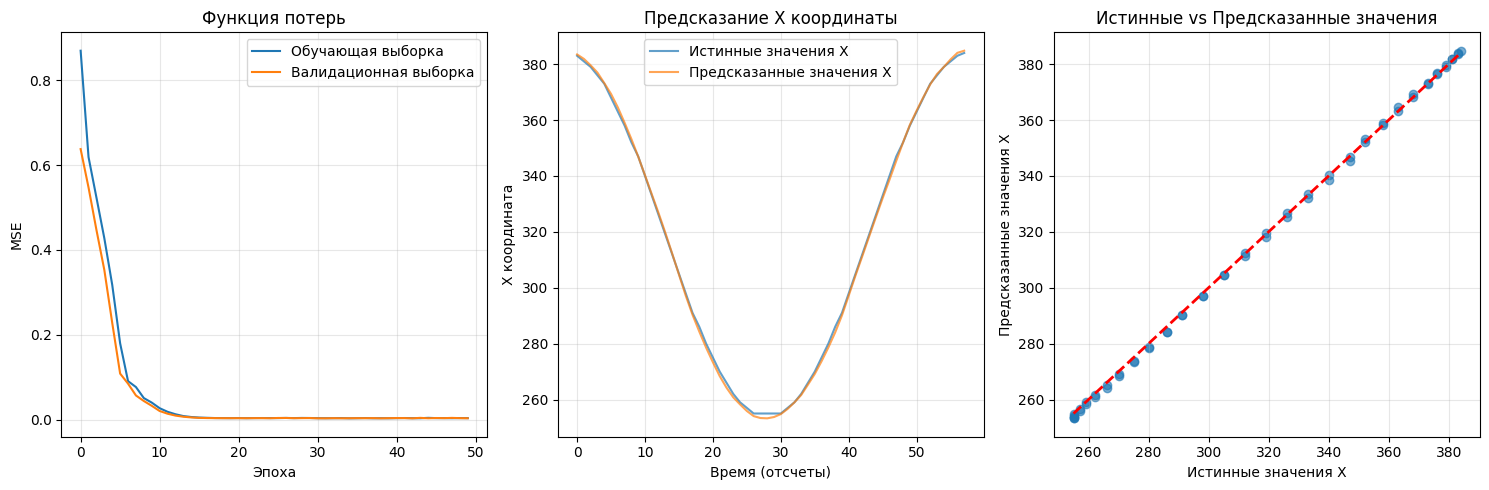

In [17]:
y_pred = model.predict(X_test)

y_pred_denorm = np.column_stack([
    y_pred[:, 0] * x_std + x_mean,
    y_pred[:, 1] * y_std + y_mean
])

y_test_denorm = np.column_stack([
    y_test[:, 0] * x_std + x_mean,
    y_test[:, 1] * y_std + y_mean
])

mse_x = np.mean((y_pred_denorm[:, 0] - y_test_denorm[:, 0])**2)
mse_y = np.mean((y_pred_denorm[:, 1] - y_test_denorm[:, 1])**2)
mae_x = np.mean(np.abs(y_pred_denorm[:, 0] - y_test_denorm[:, 0]))
mae_y = np.mean(np.abs(y_pred_denorm[:, 1] - y_test_denorm[:, 1]))

print("=== ОЦЕНКА НЕЙРОСЕТЕВОЙ МОДЕЛИ ===")
print(f"MSE для X координаты: {mse_x:.2f}")
print(f"MSE для Y координаты: {mse_y:.2f}")
print(f"MAE для X координаты: {mae_x:.2f}")
print(f"MAE для Y координаты: {mae_y:.2f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(y_test_denorm[:, 0], label='Истинные значения X', alpha=0.7)
plt.plot(y_pred_denorm[:, 0], label='Предсказанные значения X', alpha=0.7)
plt.title('Предсказание X координаты')
plt.xlabel('Время (отсчеты)')
plt.ylabel('X координата')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(y_test_denorm[:, 0], y_pred_denorm[:, 0], alpha=0.6)
plt.plot([y_test_denorm[:, 0].min(), y_test_denorm[:, 0].max()],
         [y_test_denorm[:, 0].min(), y_test_denorm[:, 0].max()], 'r--', lw=2)
plt.title('Истинные vs Предсказанные значения')
plt.xlabel('Истинные значения X')
plt.ylabel('Предсказанные значения X')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
def theoretical_pendulum_period(length_pixels, pixels_per_meter=100):
    """Вычисление теоретического периода маятника"""
    length_meters = length_pixels / pixels_per_meter
    g = 9.81

    period = 2 * np.pi * np.sqrt(length_meters / g)
    return period

In [19]:
estimated_length = analysis_results['amplitude_pixels'] * 2  # грубая оценка
theoretical_period = theoretical_pendulum_period(estimated_length)

print("=== СРАВНЕНИЕ С ТЕОРЕТИЧЕСКИМИ ЗНАЧЕНИЯМИ ===")
print(f"Измеренный период: {analysis_results['period']:.3f} сек")
print(f"Теоретический период: {theoretical_period:.3f} сек")
print(f"Относительная погрешность: {abs(analysis_results['period'] - theoretical_period) / theoretical_period * 100:.1f}%")

=== СРАВНЕНИЕ С ТЕОРЕТИЧЕСКИМИ ЗНАЧЕНИЯМИ ===
Измеренный период: 2.000 сек
Теоретический период: 2.289 сек
Относительная погрешность: 12.6%


In [20]:
def create_annotated_video(frames, positions, output_path='annotated_pendulum.mp4'):
    """Создание видео с аннотациями"""
    height, width = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, 30.0, (width, height))

    for i, (frame, pos) in enumerate(zip(frames, positions)):
        annotated_frame = frame.copy()

        if pos is not None:
            cv2.circle(annotated_frame, pos, 10, (0, 255, 0), -1)

            text = f"Frame: {i+1}, Pos: {pos}"
            cv2.putText(annotated_frame, text, (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            start_idx = max(0, i-20)
            trajectory_positions = [p for p in positions[start_idx:i+1] if p is not None]

            if len(trajectory_positions) > 1:
                trajectory_points = np.array(trajectory_positions, dtype=np.int32)
                cv2.polylines(annotated_frame, [trajectory_points], False, (255, 0, 0), 2)

        annotated_frame_bgr = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)
        out.write(annotated_frame_bgr)

    out.release()
    print(f"Аннотированное видео сохранено как {output_path}")

In [21]:
create_annotated_video(frames, [(int(x), int(y)) if x is not None else None
                                for x, y in zip(x_coords, y_coords)])

print("\n" + "="*50)
print("           ИТОГОВЫЕ РЕЗУЛЬТАТЫ АНАЛИЗА")
print("="*50)
print(f"Общее количество кадров: {len(frames)}")
print(f"Успешно обработано позиций: {len([p for p in positions if p is not None])}")
print(f"Точность детекции: {len([p for p in positions if p is not None]) / len(positions) * 100:.1f}%")
print(f"\nПараметры колебаний:")
print(f"  - Период: {analysis_results['period']:.3f} сек")
print(f"  - Частота: {analysis_results['frequency']:.3f} Гц")
print(f"  - Амплитуда: {analysis_results['amplitude_pixels']:.1f} пикселей")
print(f"\nТочность нейросетевой модели:")
print(f"  - MAE по X: {mae_x:.2f} пикселей")
print(f"  - MAE по Y: {mae_y:.2f} пикселей")
print(f"\nСравнение с теорией:")
print(f"  - Теоретический период: {theoretical_period:.3f} сек")
print(f"  - Погрешность измерения: {abs(analysis_results['period'] - theoretical_period) / theoretical_period * 100:.1f}%")
print("="*50)

Аннотированное видео сохранено как annotated_pendulum.mp4

           ИТОГОВЫЕ РЕЗУЛЬТАТЫ АНАЛИЗА
Общее количество кадров: 300
Успешно обработано позиций: 300
Точность детекции: 100.0%

Параметры колебаний:
  - Период: 2.000 сек
  - Частота: 0.500 Гц
  - Амплитуда: 65.1 пикселей

Точность нейросетевой модели:
  - MAE по X: 0.84 пикселей
  - MAE по Y: 0.44 пикселей

Сравнение с теорией:
  - Теоретический период: 2.289 сек
  - Погрешность измерения: 12.6%


In [22]:
results_data = {
    'positions': positions,
    'analysis_results': analysis_results,
    'model_metrics': {
        'mse_x': float(mse_x),
        'mse_y': float(mse_y),
        'mae_x': float(mae_x),
        'mae_y': float(mae_y)
    },
    'theoretical_comparison': {
        'measured_period': analysis_results['period'],
        'theoretical_period': theoretical_period,
        'error_percentage': abs(analysis_results['period'] - theoretical_period) / theoretical_period * 100
    }
}

import json
with open('pendulum_analysis_results.json', 'w') as f:
    serializable_results = {}
    for key, value in results_data.items():
        if isinstance(value, dict):
            serializable_results[key] = {}
            for k, v in value.items():
                if isinstance(v, np.ndarray):
                    serializable_results[key][k] = v.tolist()
                else:
                    serializable_results[key][k] = v
        elif isinstance(value, list):
            serializable_results[key] = [pos if pos is None else list(pos) if isinstance(pos, tuple) else pos for pos in value]
        else:
            serializable_results[key] = value

    json.dump(serializable_results, f, indent=2)

print("Результаты сохранены в файл pendulum_analysis_results.json")
print("\nАнализ завершен успешно!")

Результаты сохранены в файл pendulum_analysis_results.json

Анализ завершен успешно!


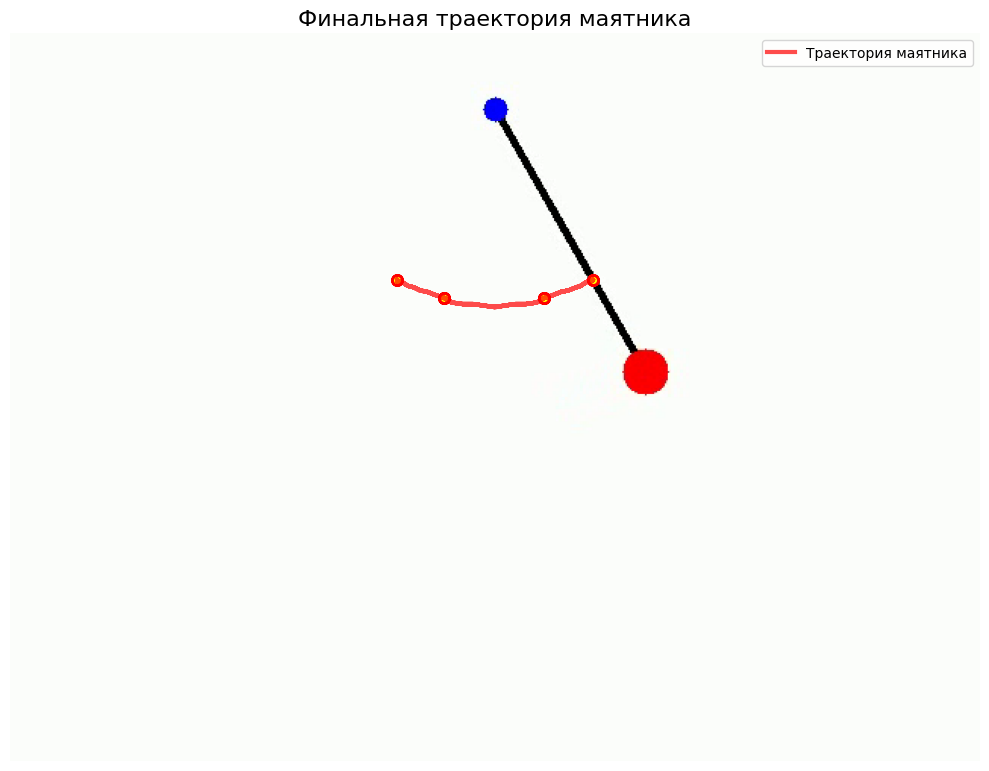

In [23]:
plt.figure(figsize=(10, 8))
plt.imshow(frames[-1])
plt.plot(x_coords, y_coords, 'r-', linewidth=3, alpha=0.7, label='Траектория маятника')
plt.scatter(x_coords[::10], y_coords[::10], c='yellow', s=50, edgecolor='red', linewidth=2)
plt.title('Финальная траектория маятника', fontsize=16)
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()